<h1>Prefata</h1>

**Re-Volt** este un joc de curse cu mașini radiocomandate dezvoltat de Acclaim, lansat inițial în 1999. Acesta oferă un gameplay excelent, mai multe moduri de joc și o fizică realistă, împreună cu elemente vizuale luminoase și colorate care rezistă și astăzi.
Este un joc destinat nu doar celor care vor doar să joace un joc arcade retro de curse, ci și celor care caută o provocare mai competitivă.
		Comunitatea Re-Volt I/O, ține jocul în viață și astăzi și organizează sesiuni oficiale la care se poate participa pe bază de IP. 
		Datele acestor curse sunt salvate la [online.re-volt.io](https://online.re-volt.io/sessions/results.php).
		Motivația acestui proiect este de a descoperi prin metodele Big Data, propuse în cadrul Curriculei, tiparele jucătorilor de astăzi, în contextul unui joc care a lăsat o amprentă asupra copilăriei mele.

<h1>Pregatirea succinta a setului de date</h1>
Datele din [online.re-volt.io](https://online.re-volt.io/sessions/results.php) sunt stocate în format CSV și conțin obsevații formate din Jucător, mașină, hartă și timp sau scor și câștiguri obținute în sesiune. Am ales sa explorez doar sesiunile care s-au petrecut dupa `1-JAN-2023`.

Un exemplu de session_2023-01-03_20-00-00 este in urmatoarele 2 celule si output:

In [219]:
read_file = open('Sessions/session_2026-01-15_20-01-03.csv&generate', 'r').read()

In [220]:
read_file

'Parsed,"01/15/26 20:07:18","RADIANCER","Arcade",5,"Enabled"\nScore\n#,Player,Cars,"Galaxy World 2","Spa-Volt 1","Museum 3","Lunar","Biohazard Factory","Ghost Town 1 R","Fairground 1","Grisville R","Route-77","Aquarium 1","Elementary 2","Casino RV","Sakura R","Toy World 2",Wins\n1,"RADIANCER","Dual Signal",9,9,9,8,10,10,7,12,12,11,13,12,12,10,9\n2,"ZEROMIST","Karlington",10,7,8,9,9,6,12,11,10,9,12,10,11,7,3\n3,"LOLBIT","Zipper,Maxam RS",8,8,7,6,6,7,9,10,11,8,11,6,13,14,2\n4,"JSN","Dragoon,Zipper,Dual Signal",4,5,6,7,5,8,11,7,6,6,4,7,9,8,0\n5,"AKB","Acclaim GT,Adeon",0,0,0,5,7,9,8,5,8,10,6,8,8,13,0\n6,"NOZO","Adeon",0,0,0,0,0,5,10,8,9,5,9,5,10,2,0\n7,"Z3TA2K26","Pemto,RC Vector,Ontogen,Heritage,Chubba,Styn,Arnoux,Swede",0,0,0,0,0,0,6,9,7,7,8,11,7,5,0\n8,"BAPT","Acclaim GT",2,6,5,2,2,3,1,3,5,4,2,3,3,6,0\n9,"THEMAN","Adeon",0,0,0,0,8,4,4,4,4,3,0,4,4,4,0\n10,"1NTERNO","Zipper",7,0,3,0,0,0,5,6,3,0,5,0,0,9,0\n11,"ADEON USER","Adeon",0,0,0,0,0,0,0,0,0,0,10,9,5,12,0\n12,"1Q2W3E4R","Adeon",5,4,

In [1]:
import os
import io
import csv
import pandas as pd
import re

# Declar folder unde stochez sesiunile cu date crude de la adresa
input_folder = "Sessions"

# Declar dataset-ul final, prelucrat
output_master_csv = "revolt_master_dataset.csv"

In [2]:
# RegEx-ul `pattern` match-uieste Id-urile numerice ale jucatorilor.

pattern = r"\n(\d{1,2})"

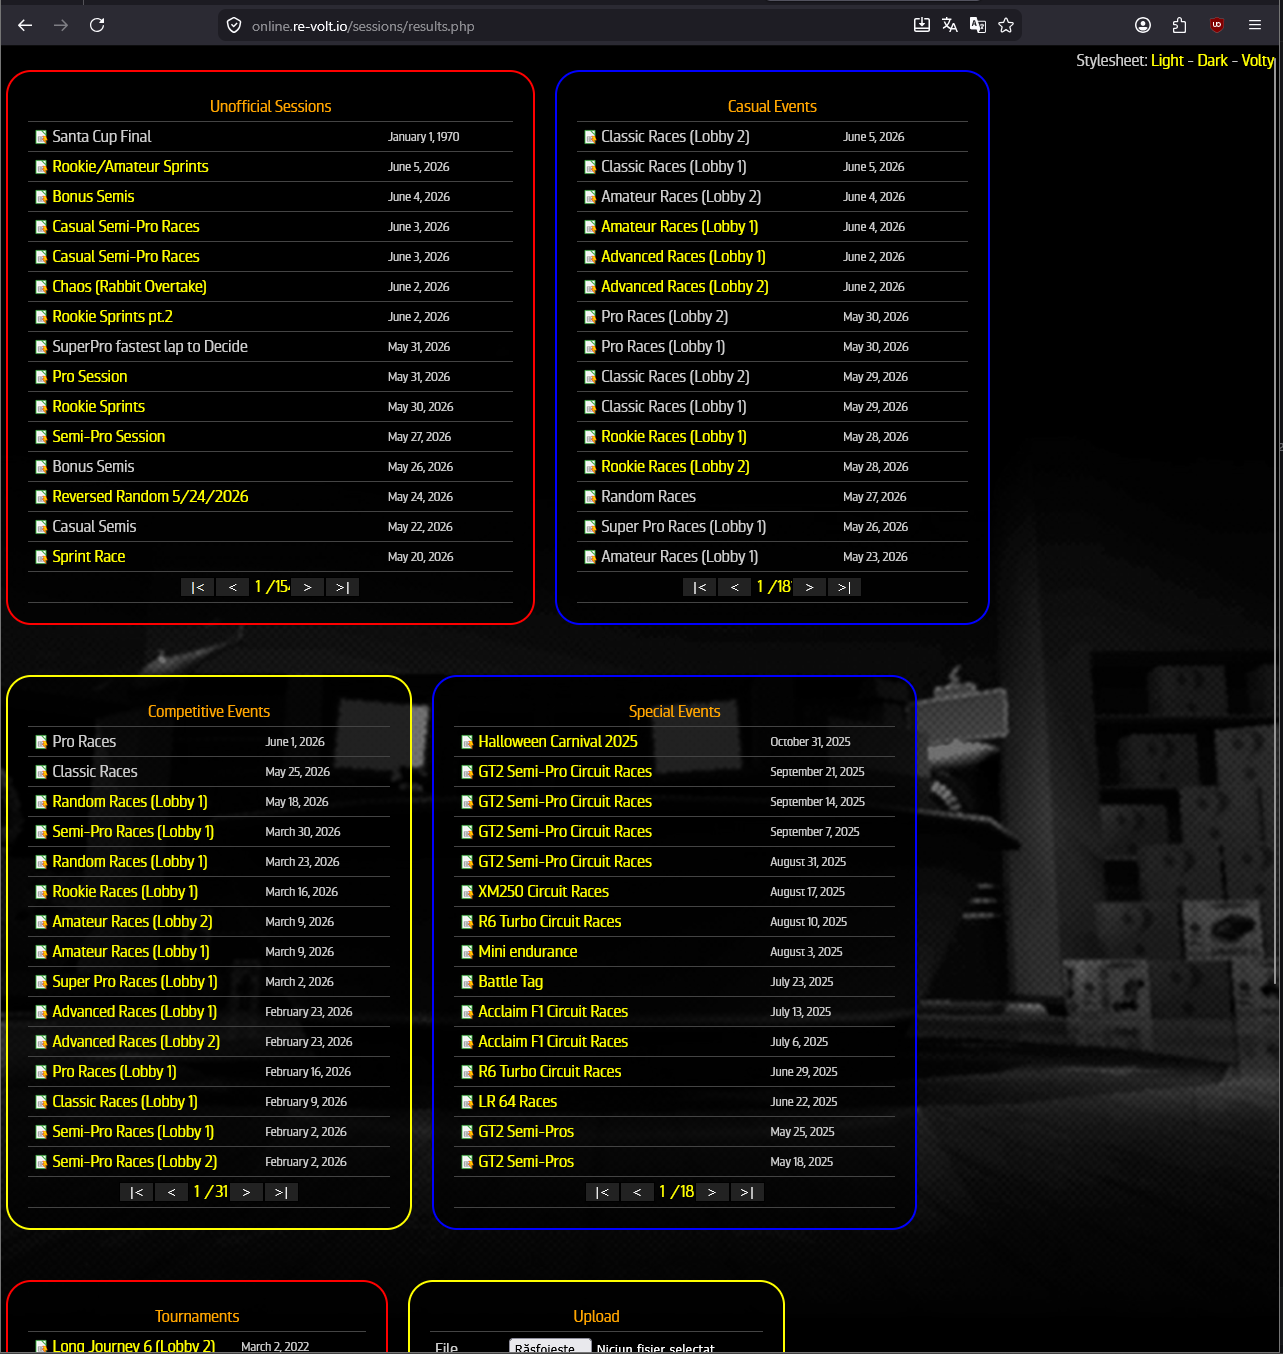

In [3]:
all_race_stats = []

In [9]:
# Iterare prin fisierele cu date crude
for filename in os.listdir(input_folder):
    file_path = os.path.join(input_folder, filename)

    if os.path.isdir(file_path) or not filename.endswith("&generate"):
        continue
    session_id = filename.replace(".csv&generate", "")

    single_session = open(file_path, 'r').read()

    # Identificarea tuturor Id-urilor numerice ale jucatorilor
    player_session_Ids = [int(id) for id in re.findall(pattern, single_session)]

    # Selectarea Id-ului maxim, util imediat pentru descoperirea numarului de randuri de extras din CSV
    max_player_id = max(player_session_Ids)

    # Citeste sectiunea care contine scorurile din cursa
    score_string = open(file_path, 'r').readlines()[2:(max_player_id+3)]

    # Citeste sectiunea care contine timpii din cursa
    time_string = open(file_path, 'r').readlines()[(max_player_id+4):]

    score_csv = "".join(score_string)
    time_csv = "".join(time_string)

    score_df = pd.read_csv(io.StringIO(score_csv))
    time_df = pd.read_csv(io.StringIO(time_csv))

    # Manipulare - long form
    scores_by_track = pd.melt(score_df, id_vars=['#', 'Player', 'Cars', 'Wins'], var_name='Track', value_name='Points')
    
    # Manipulare - long form
    times_by_track = pd.melt(time_df, id_vars=['#', 'Player', 'Cars'], var_name='Track', value_name='Time(ms)')

    race_stats = scores_by_track.merge(times_by_track, on= ['Player', 'Cars', 'Track']).drop(['#_x', '#_y'], axis=1)
    race_stats['Session_Id'] = session_id

    #Construire dataset final
    all_race_stats.append(race_stats)

master_df = pd.concat(all_race_stats, ignore_index=True)
print(f"Master file saved as: {os.path.abspath(output_master_csv)}")

# Se poate deschide revolt_master_dataset.csv din Director.

Master file saved as: /home/jovyan/ReVolt - BigData Project/revolt_master_dataset.csv


**Rezultatele** asa cum sunt ele anuntate pe canalul de comunicare

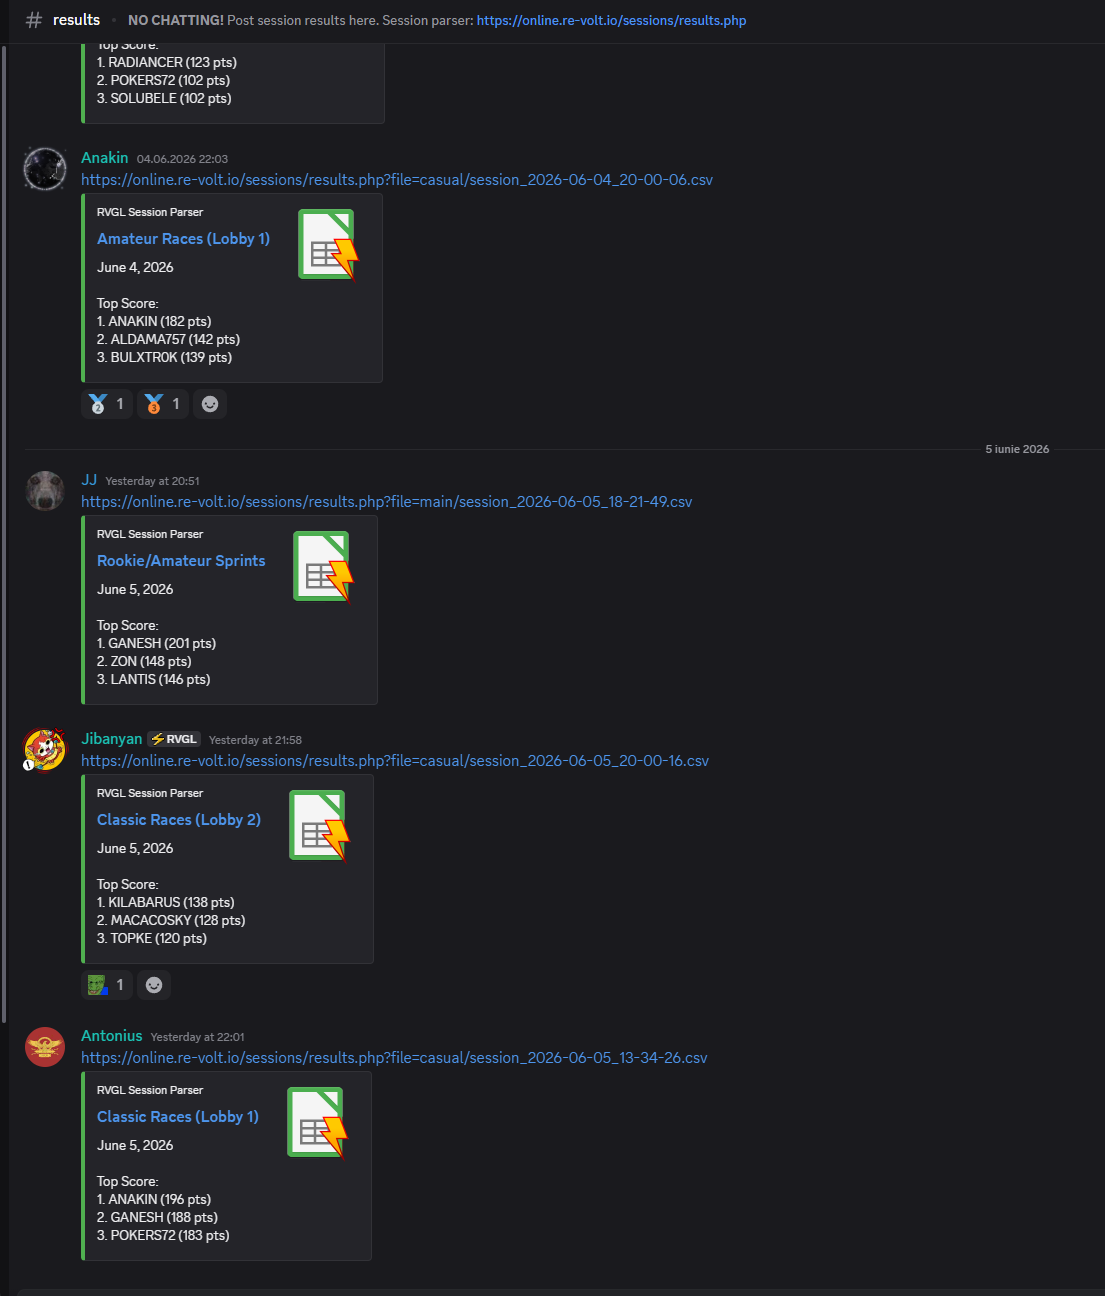

<h1>Grupări și agregări de date</h1>

In [105]:
from pyspark import SparkContext as sc
from pyspark.sql import SparkSession, functions, Column
from pyspark.sql.functions import when, col, regexp_replace
import pandas as pd
import os
import io
import csv
import pandas as pd
import re

In [4]:
# Crearea unui context Spark
sparkRVGL = SparkSession.builder.appName('RVGL').getOrCreate()

In [6]:
revolt_df = sparkRVGL.read.csv('revolt_master_dataset.csv',inferSchema=True,header=True)

In [13]:
# Statistice descriptive, doar coloanele numerice
revolt_df.describe().select(['summary', 'Points', 'Time(ms)']).show()

+-------+-----------------+------------------+
|summary|           Points|          Time(ms)|
+-------+-----------------+------------------+
|  count|          1581716|           1581716|
|   mean|6.444957881187268|206646.90057507163|
| stddev|4.775333803622339|57930.671433547555|
|    min|                0|             75405|
|    max|               16|            619540|
+-------+-----------------+------------------+



In [23]:
df.createOrReplaceTempView("revolt_master_dataset")

In [64]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [68]:
# Cursele mele, prin Spark SQL
my_sessions = sparkRVGL.sql(f"SELECT * FROM revolt_master_dataset WHERE Player = 'VALI2WD'").show(n=20, truncate=False)

# Sesiunie mele, in care am castigat minim o cursa, prin Spark SQL.
my_wins = sparkRVGL.sql(f"SELECT Session_Id, AVG(Points) FROM revolt_master_dataset WHERE Player = 'VALI2WD' AND Wins > 1 GROUP BY Session_Id").show(n=20, truncate=False)

+-------+------------+----+--------------------------------+------+--------+---------------------------+
|Player |Cars        |Wins|Track                           |Points|Time(ms)|Session_Id                 |
+-------+------------+----+--------------------------------+------+--------+---------------------------+
|VALI2WD|Stinger     |0   |Toy World Aquatica: Redux       |11    |178140  |session_2026-05-14_19-59-55|
|VALI2WD|Stinger     |0   |Toys in the Hood 2              |12    |220621  |session_2026-05-14_19-59-55|
|VALI2WD|Stinger     |0   |Jailhouse Rock                  |13    |176126  |session_2026-05-14_19-59-55|
|VALI2WD|Stinger     |0   |Galaxy World 1 R                |11    |202075  |session_2026-05-14_19-59-55|
|VALI2WD|Stinger     |0   |Downtown 1                      |13    |156781  |session_2026-05-14_19-59-55|
|VALI2WD|Stinger     |0   |Radioactive Garden              |10    |186319  |session_2026-05-14_19-59-55|
|VALI2WD|Stinger     |0   |Toy World 3                 

In [55]:
# Jucatorii cu cele mai multe puncte acumulate, Spark SQL
points_leaderboard =  sparkRVGL.sql(f"SELECT Player, SUM(Points) AS Total_Points FROM revolt_master_dataset WHERE GROUP BY Player ORDER BY Total_Points DESC LIMIT 30").show()

+------------+------------+
|      Player|Total_Points|
+------------+------------+
|   RADIANCER|      481577|
|   KILABARUS|      321165|
|         ROG|      294212|
|   MACACOSKY|      274975|
|    POKERS72|      216191|
|      ANAKIN|      206715|
|          MX|      202371|
|   ALDAMA757|      194258|
|       TOPKE|      188789|
|         ROD|      187189|
|     SKANDAR|      176862|
|    POWERATE|      167919|
|        ZIGC|      135444|
|    SOLUBELE|      135169|
|         YAM|      124938|
|FROSTTBITTEN|      121792|
|      LEKTOR|      118796|
|   LAGGEEROK|      118707|
|        AHMA|      109137|
| SKILLYPEACY|      108999|
+------------+------------+
only showing top 20 rows



In [46]:
# Grupare pe baza hartii.
revolt_session_tracks = revolt_df.select(['Track', 'Session_Id']).distinct().groupby('Track')

In [50]:
# Cele mai jucate harti, Spark DF
revolt_session_tracks.agg({'Session_Id':'count'}).withColumnRenamed('count(Session_Id)', 'Times Played').orderBy('Times Played', ascending=False).show()

+------------------+------------+
|             Track|Times Played|
+------------------+------------+
|Toys in the Hood 2|         426|
|     SuperMarket 1|         401|
|          Rooftops|         396|
|          Museum 2|         390|
|       Toy World 2|         389|
|          Museum 1|         388|
|     SuperMarket 2|         387|
|Toys in the Hood 1|         385|
|      Ghost Town 1|         384|
|       Toy World 1|         383|
|  Botanical Garden|         382|
|        Toytanic 2|         377|
|      Ghost Town 2|         375|
|        Toytanic 1|         337|
|             Lunar|         266|
|         Santorini|         238|
|          StadVolt|         232|
|            Venice|         231|
|            Home 2|         229|
|       Game Room 2|         228|
+------------------+------------+
only showing top 20 rows



Hartile, asa cum apar ele prezentate pe [ReVolt IO](https://re-volt.io/)

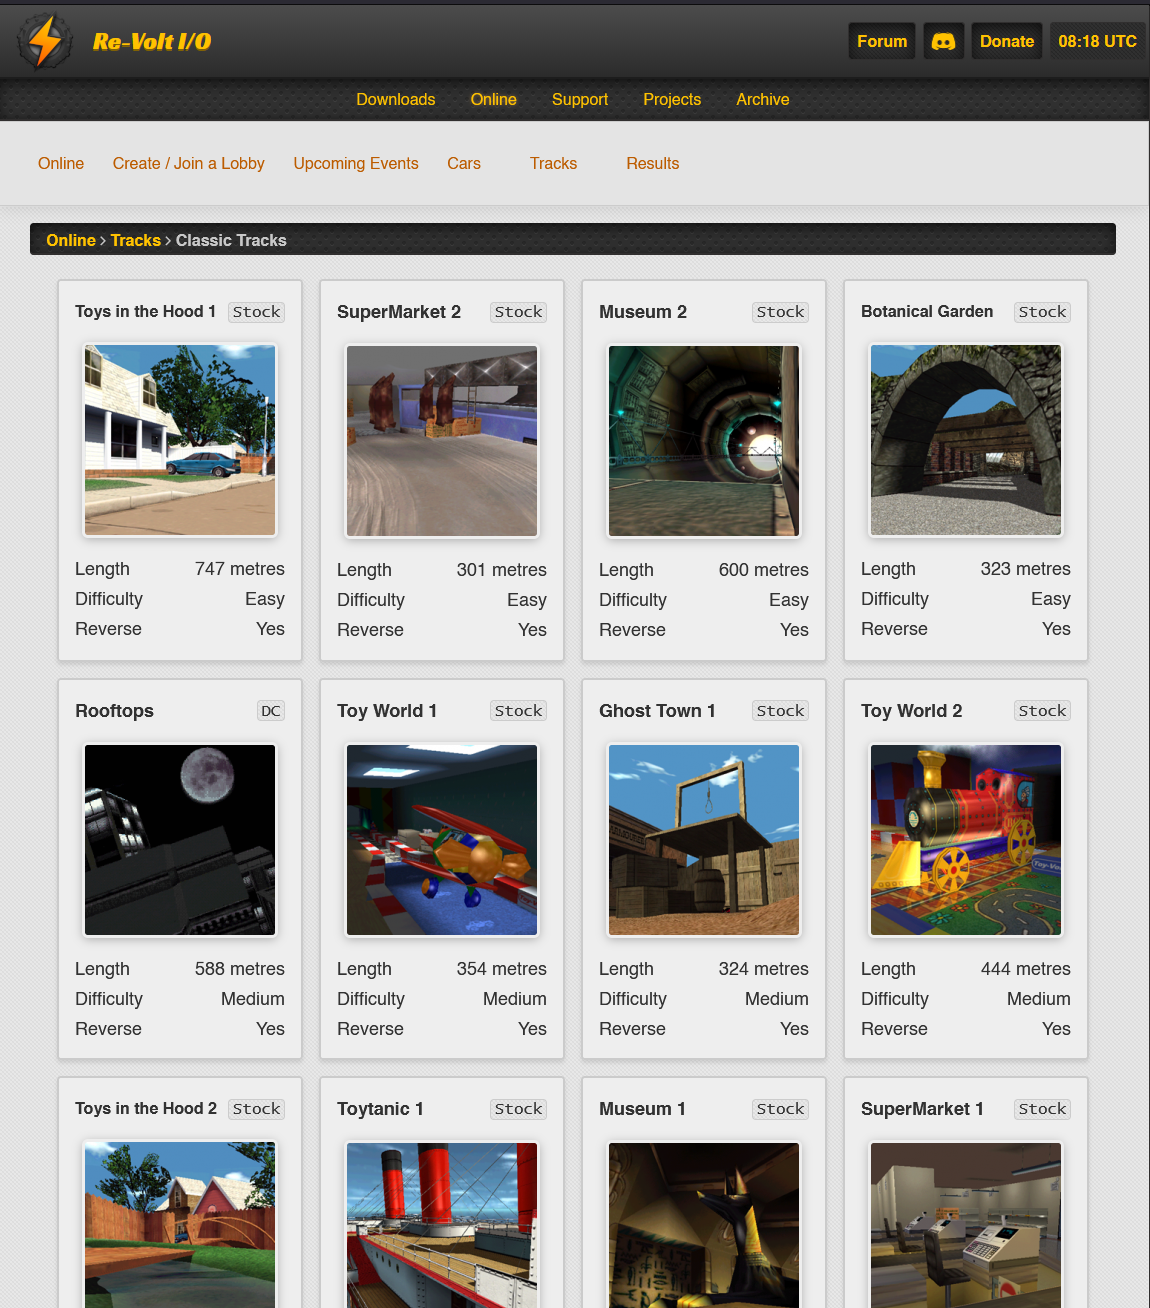

In [85]:
# Masinile si timpul lor mediu, ordonate crescator dupa timp, Spark SQL.
points_leaderboard =  sparkRVGL.sql(f"SELECT Cars, AVG(`Time(ms)`) AS `Average_Car_Time(ms)` FROM revolt_master_dataset WHERE Cars NOT LIKE '%,%' GROUP BY Cars ORDER BY `Average_Car_Time(ms)`").show()

+-----------+--------------------+
|       Cars|Average_Car_Time(ms)|
+-----------+--------------------+
|   Spectrum|  159042.92857142858|
|    Tizzoni|  170424.82142857142|
|   Rustique|   171873.7142857143|
|    RVRC 20|        171881.53125|
|       Khan|  173675.85714285713|
|    Warrion|  173923.57142857142|
|   Champion|  174226.07142857142|
|S13 Alltune|            175837.0|
|     Celiod|   177241.7619047619|
|     Indy B|  178905.94642857142|
|    Norwood|  178974.20408163266|
| Sentaro XL|  179341.77876106196|
|  Road King|  179731.15714285715|
|     E-Razr|  180274.18095238096|
|  Crazy Pat|  180375.51260504202|
|        BLK|  180965.07142857142|
|      Karen|  181974.22222222222|
|    Middle5|   182196.1043956044|
|      Sturm|  182876.47802197802|
|    Clubman|  182885.92857142858|
+-----------+--------------------+
only showing top 20 rows



Masinile, asa cum apar ele prezentate pe [ReVolt IO](https://re-volt.io/)

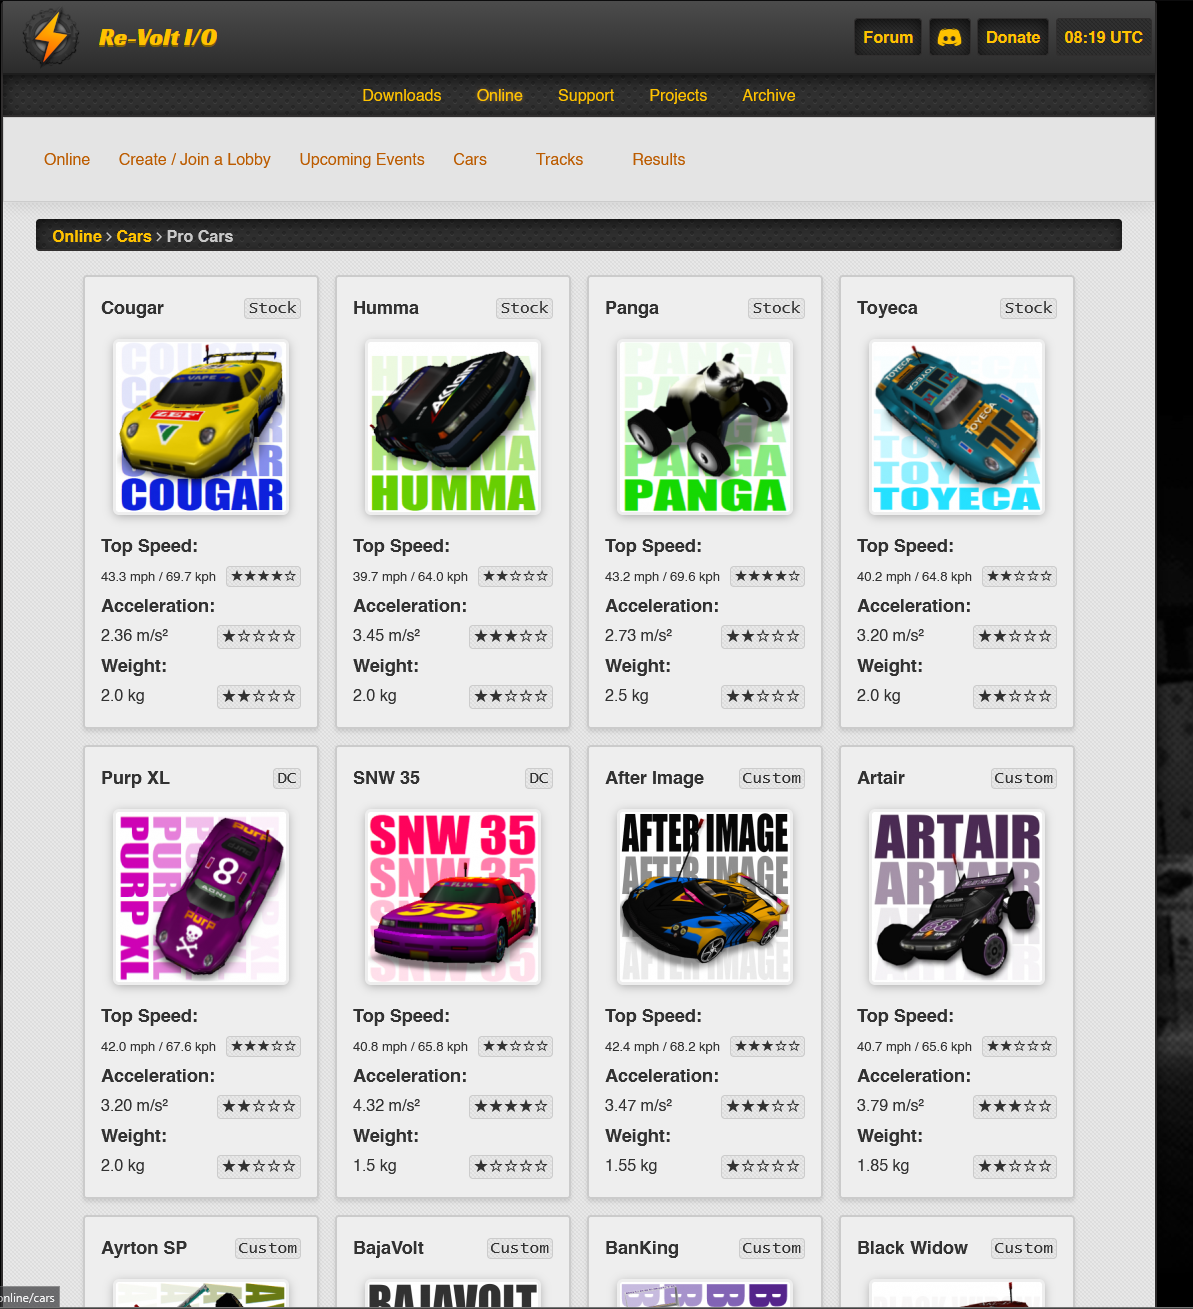

In [93]:
# RegEx care match-uieste `R` din finalul unei denumiri de harta.
reverse_map_pattern = r"\sR$"

In [126]:
# Marcarea hartilor in Reverse printr-o coloana noua, bazat pe `R` din denumirea hartii.
revolt_split_by_reverse = revolt_df.withColumn(
    'IsReverse', 
    when(col('Track').rlike(reverse_map_pattern), 1).otherwise(0)
).withColumn(
    "Track", 
    regexp_replace(col("Track"), r"\s+R$", "")
).createOrReplaceTempView("revolt_split_by_reverse")

In [133]:
# Utilizarea CTE-urilor in Spark SQL.
# Descoperirea hartilor care sunt mai rapide in medie, in sens invers de parcurs.
faster_in_reverse_df = sparkRVGL.sql("""
    WITH Forward_Times AS (
        SELECT Track, AVG(`Time(ms)`) AS Avg_Forward
        FROM revolt_split_by_reverse 
        WHERE IsReverse = 0 
        GROUP BY Track
    ),
    Reverse_Times AS (
        SELECT Track, AVG(`Time(ms)`) AS Avg_Reverse
        FROM revolt_split_by_reverse 
        WHERE IsReverse = 1 
        GROUP BY Track
    )
    SELECT 
        f.Track, 
        f.Avg_Forward, 
        r.Avg_Reverse
    FROM Forward_Times f
    INNER JOIN Reverse_Times r ON f.Track = r.Track
    WHERE r.Avg_Reverse < f.Avg_Forward
    ORDER BY (f.Avg_Forward - r.Avg_Reverse) DESC
""")

faster_in_reverse_df.show(n=100, truncate=False)

+--------------------------------+------------------+------------------+
|Track                           |Avg_Forward       |Avg_Reverse       |
+--------------------------------+------------------+------------------+
|Radio Kootwijk                  |278000.9666666667 |178605.88571428572|
|Mansion                         |243084.95652173914|208272.37209302327|
|Ghost Town 2                    |219953.14478306274|202752.17141522653|
|Snowland 1                      |176051.8276923077 |160004.67142857143|
|Holiday Camp: California Edition|233476.84300791557|217448.7920410783 |
|Spa-Volt 2                      |201919.33243998402|189445.70546163848|
|Toys in the Hood 5              |209568.14705882352|197902.8947368421 |
|ToySoldierz                     |218741.36931386616|207241.9044117647 |
|Home 1                          |210712.1303744799 |201049.81697612733|
|The Bunker                      |198471.04264922623|189385.85968819598|
|Castle 1                        |225853.4812916453

<h1>Machine Learning</h1>

In [1]:
# Importuri
from pyspark import SparkContext as sc
from pyspark.sql import SparkSession, functions, Column, Row
from pyspark.sql.functions import when, col, regexp_replace, count, avg, stddev, sum
import pandas as pd
import os
import io
import csv
import pandas as pd
import re
import pyspark.pandas as ps
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import udf, col
from pyspark.sql.types import StringType

/usr/local/spark/python/pyspark/pandas/__init__.py:50: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


In [2]:
sparkRVGL = SparkSession.builder.appName('RVGL').config("spark.driver.memory", "8g").config("spark.executor.memory", "8g").getOrCreate()

In [3]:
revolt_df = sparkRVGL.read.csv('revolt_master_dataset.csv',inferSchema=True,header=True)

In [4]:
# Agregare a datelor in functie de jucator, crearea de coloane cu punctaj mediu, deviatia standard a fiecarui jucator si numarul de curse la care a participat.

player_stats = revolt_df.groupBy("Player").agg(
    count("Session_ID").alias("Total_Races"),
    avg("Points").alias("Avg_Points"),
    stddev("Points").alias("Consistency_Index"), # Lower is more consistent
    sum(when(col("Time(ms)") == 0, 1).otherwise(0)).alias("DNF_Count")
)

In [5]:
# Curatare a datelor cu fillna
player_stats = player_stats.fillna(0, subset=["Consistency_Index"])

In [6]:
# Pastram doar jucatorii care au parcurs un minim de 100 de curse. 
# De ce?  Pentru consistenta datelor si integritate, stergem jucatorii cu experienta de pe conturi noi (smurf), 
# jucatorii care glumesc folosind alte nume(trolleri) sau noi-veniti care parasesc jocul prea repede.

robust_players = player_stats.filter(col("Total_Races") >= 100).withColumn("DNF_Rate", col("DNF_Count") / col("Total_Races"))

In [7]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, MaxAbsScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

In [8]:
# Vector Assembler din punctaj mediu, deviatie standard de punctaje, si rata deconectarii de la cursa ( rar in practica ).
assembler = VectorAssembler(
    inputCols=["Avg_Points", "Consistency_Index", "DNF_Rate"],
    outputCol="raw_features"
)

In [9]:
# Scalarea datelor, pentru a permite algoritmului sa invete.
scaler = MaxAbsScaler(inputCol="raw_features", outputCol="scaled_features")

In [10]:
# Boilerplate de KMeans si evaluare, am ales 4 clustere incercand sa deosebesc intre incepatori, novice, avansat si expert.
kmeans = KMeans(featuresCol="scaled_features", k=4, seed=42)

In [11]:
pipeline = Pipeline(stages=[assembler, scaler, kmeans])
model = pipeline.fit(robust_players)

In [12]:
clustered_players = model.transform(robust_players)

In [13]:
evaluator = ClusteringEvaluator(featuresCol="scaled_features")
silhouette = evaluator.evaluate(clustered_players)
print(f"Silhouette with squared euclidean distance = {silhouette}")

# Show the players with their new assigned 'prediction' cluster
clustered_players.select("Player", "Avg_Points", "prediction").show(10)

Silhouette with squared euclidean distance = 0.5991581086340525
+-----------+------------------+----------+
|     Player|        Avg_Points|prediction|
+-----------+------------------+----------+
|     URIZOL| 4.957875457875458|         0|
|       KIKI|10.083969465648854|         3|
|    JOHNSON|0.8857142857142857|         1|
|MAKAVELI_PC| 5.035714285714286|         0|
|  MK-CHAKRA|1.3571428571428572|         1|
|        BGM|10.089285714285714|         3|
|      SAMER|0.7619047619047619|         1|
|     MISS_M|1.8673469387755102|         1|
|       AEOE|2.0348837209302326|         1|
|     TANTRA| 4.428571428571429|         0|
+-----------+------------------+----------+
only showing top 10 rows



In [14]:
# Eu
clustered_players.filter(col("Player") =='VALI2WD').drop(col('raw_features'), col('scaled_features')).show()

# Veterani ai jocului; persoane care mi-au cerut sa le determin scorul.
clustered_players.filter(col("Player") =='KILABARUS').drop(col('raw_features'), col('scaled_features')).show()
clustered_players.filter(col("Player") =='MACACOSKY').drop(col('raw_features'), col('scaled_features')).show()
clustered_players.filter(col("Player") =='RADIANCER').drop(col('raw_features'), col('scaled_features')).show()
clustered_players.filter(col("Player") =='FROSTTBITTEN').drop(col('raw_features'), col('scaled_features')).show()
clustered_players.filter(col("Player") =='GANESH').drop(col('raw_features'), col('scaled_features')).show()

+-------+-----------+-----------------+-----------------+---------+--------+----------+
| Player|Total_Races|       Avg_Points|Consistency_Index|DNF_Count|DNF_Rate|prediction|
+-------+-----------+-----------------+-----------------+---------+--------+----------+
|VALI2WD|       2016|8.197916666666666|3.506111732233899|        0|     0.0|         3|
+-------+-----------+-----------------+-----------------+---------+--------+----------+

+---------+-----------+------------------+-----------------+---------+--------+----------+
|   Player|Total_Races|        Avg_Points|Consistency_Index|DNF_Count|DNF_Rate|prediction|
+---------+-----------+------------------+-----------------+---------+--------+----------+
|KILABARUS|      30586|10.500392336363042| 4.32050324061313|        0|     0.0|         3|
+---------+-----------+------------------+-----------------+---------+--------+----------+

+---------+-----------+-----------------+------------------+---------+--------+----------+
|   Player|T

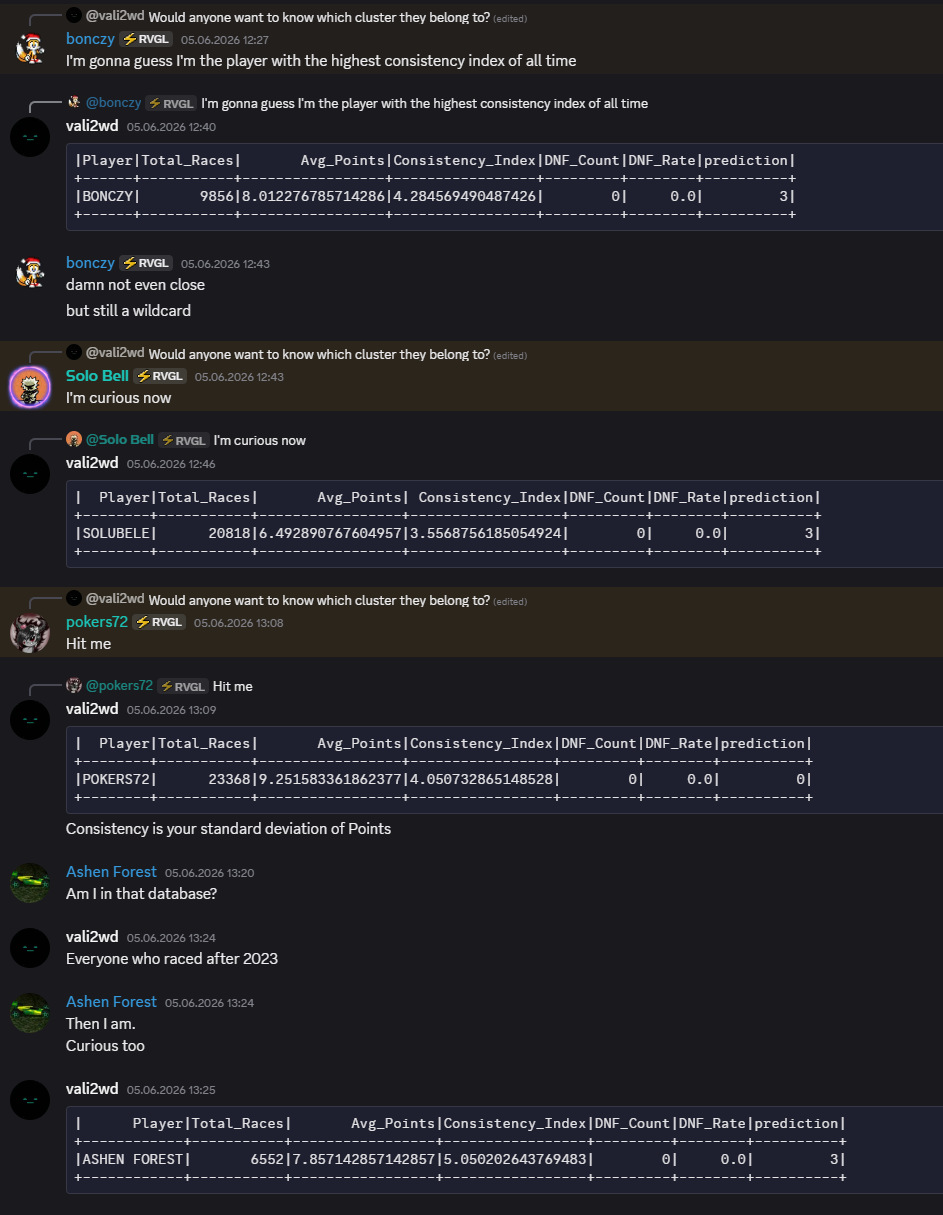

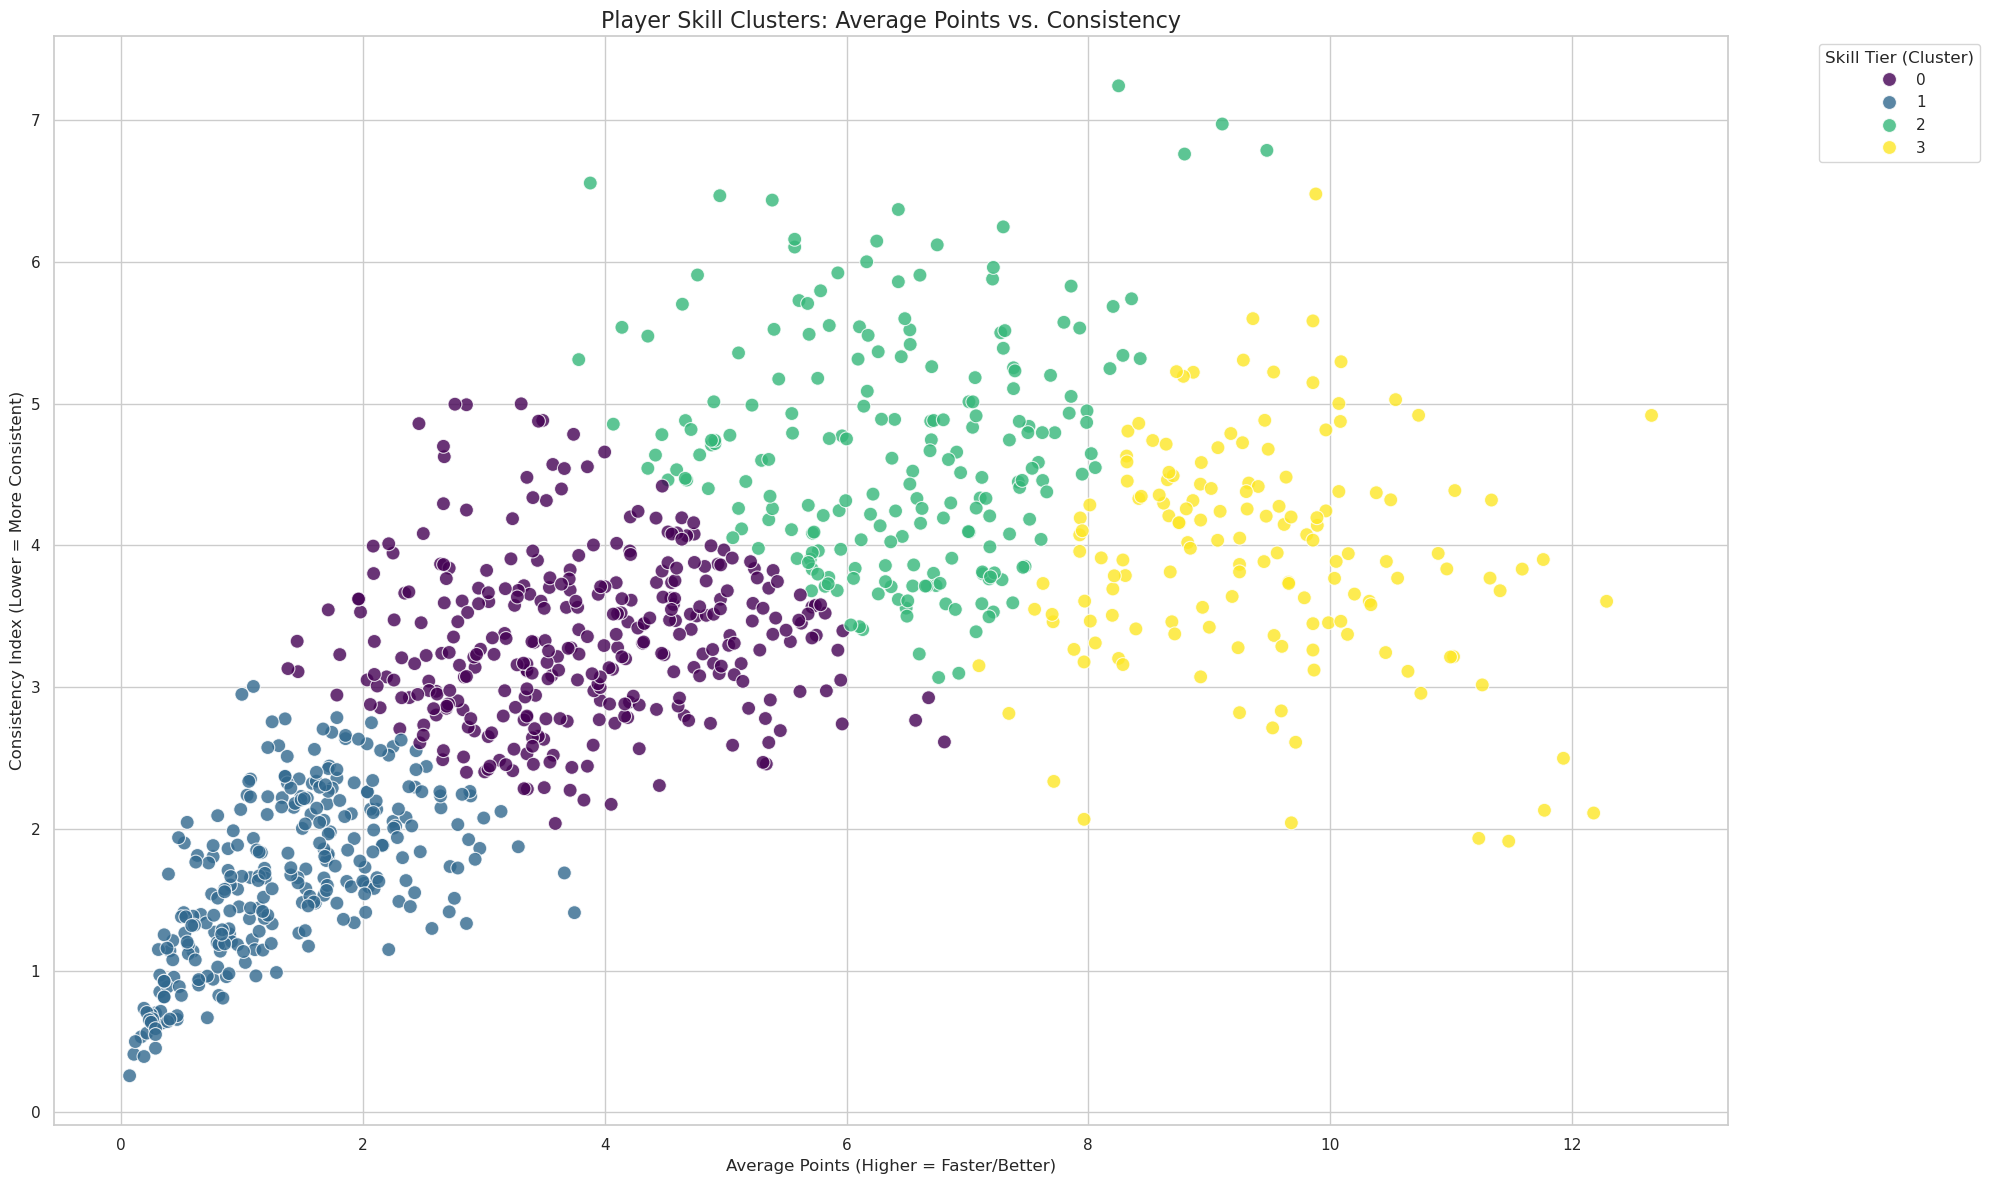

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boilerplate pentru crearea scatterplot pe baza clusterizarii.
pdf_clusters = clustered_players.select("Player", "Avg_Points", "Consistency_Index", "DNF_Rate", "prediction").toPandas()

plt.figure(figsize=(20, 12))
sns.set_theme(style="whitegrid")

scatter = sns.scatterplot(
    data=pdf_clusters,
    x="Avg_Points",
    y="Consistency_Index",
    hue="prediction",
    palette="viridis",
    s=100,
    alpha=0.8
)

plt.title("Player Skill Clusters: Average Points vs. Consistency", fontsize=16)
plt.xlabel("Average Points (Higher = Faster/Better)", fontsize=12)
plt.ylabel("Consistency Index (Lower = More Consistent)", fontsize=12)

plt.legend(title='Skill Tier (Cluster)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

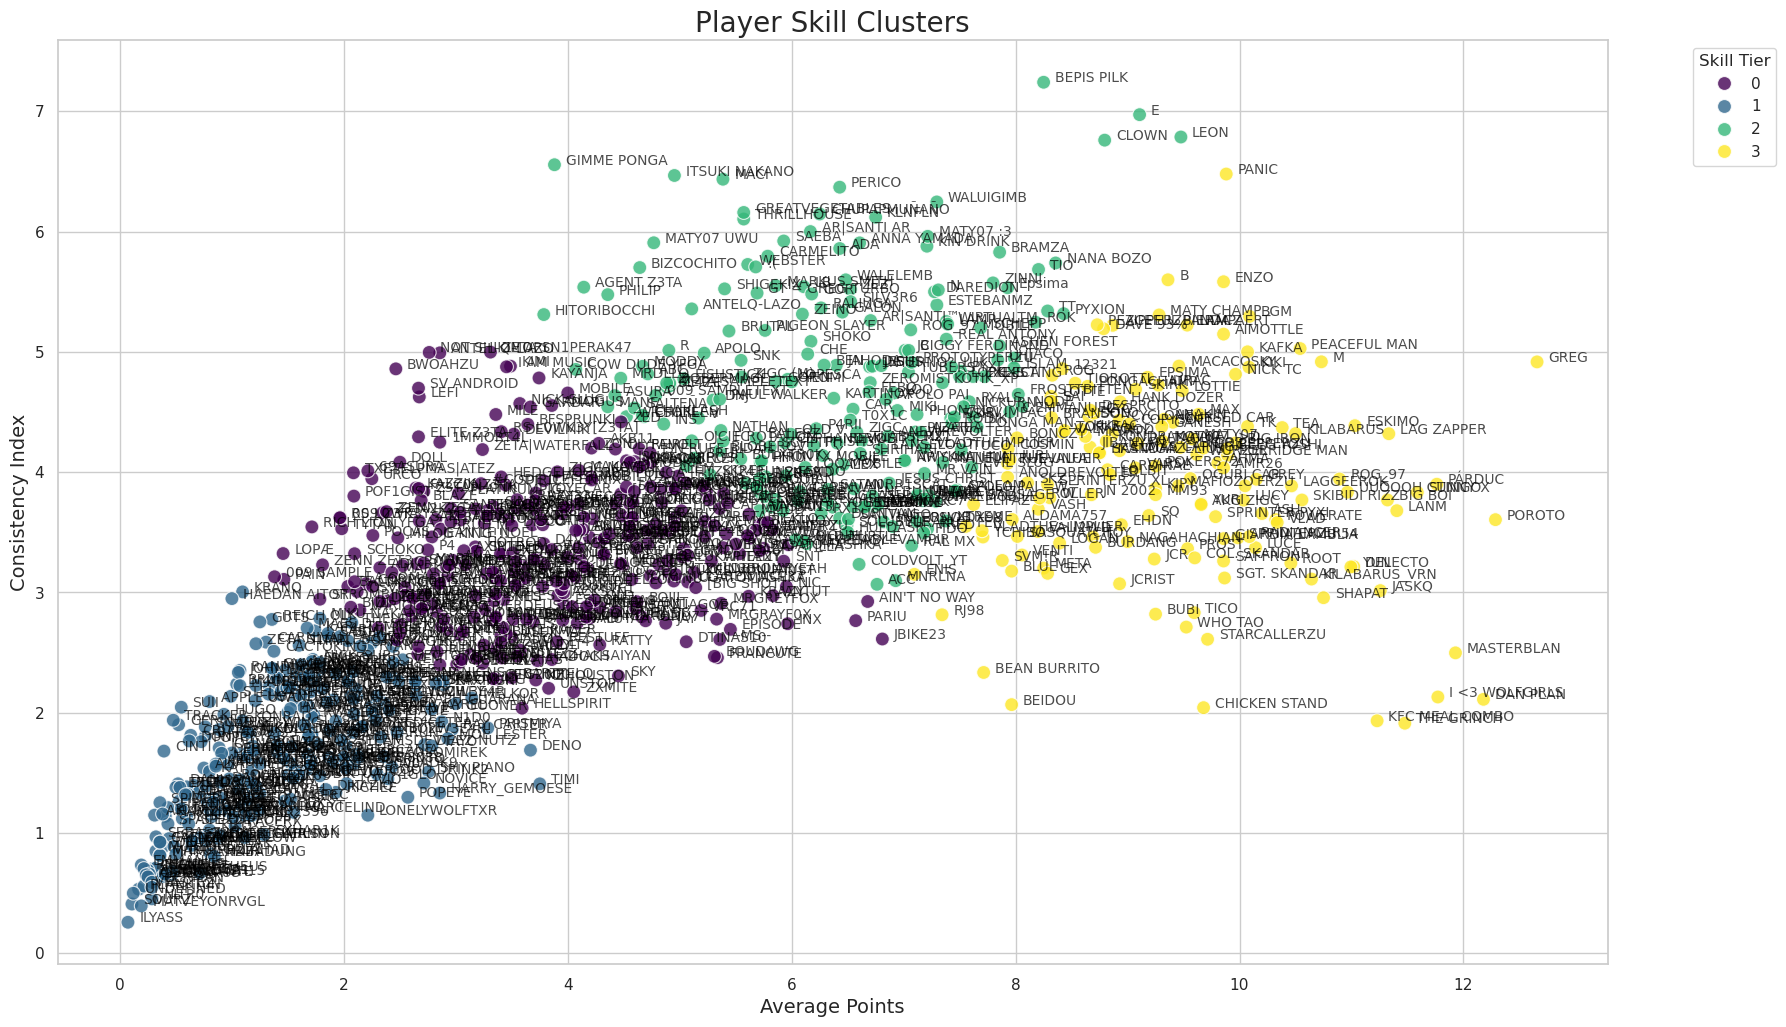

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boilerplate pentru crearea scatterplot pe baza clusterizarii - dimensiune mare

plt.figure(figsize=(20, 12))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=pdf_clusters, x="Avg_Points", y="Consistency_Index", 
    hue="prediction", palette="viridis", s=100, alpha=0.8
)

for line in range(0, pdf_clusters.shape[0]):
    plt.text(
        pdf_clusters.Avg_Points[line] + 0.1,
        pdf_clusters.Consistency_Index[line], 
        pdf_clusters.Player[line], 
        horizontalalignment='left', 
        size='small', 
        color='black', 
        alpha=0.7
    )

plt.title("Player Skill Clusters", fontsize=20)
plt.xlabel("Average Points", fontsize=14)
plt.ylabel("Consistency Index", fontsize=14)
plt.legend(title='Skill Tier', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig("massive_cluster_plot.png", dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# Redenumire coloana prediction in Skill_Tier
player_tiers = clustered_players.withColumnRenamed('prediction', 'Skill_Tier').select(col('Player'), col('Skill_Tier'))

In [18]:
# Prepararea unui set de date din curse si clasa jucatorului din observatie, fara a-l include
races_with_skillTier = revolt_df.filter(col('Time(ms)')>0) \
                                .join(player_tiers, on='Player', how='inner') \
                                .select("Track", "Cars", "Skill_Tier", "Time(ms)") \
                                .dropna()

In [19]:
races_with_skillTier.head(5)

[Row(Track='Toys in the Hood 1', Cars='Humma', Skill_Tier=0, Time(ms)=155213),
 Row(Track='SuperMarket 2', Cars='Humma', Skill_Tier=0, Time(ms)=185123),
 Row(Track='Museum 2', Cars='Humma', Skill_Tier=0, Time(ms)=189195),
 Row(Track='Botanical Garden', Cars='Humma', Skill_Tier=0, Time(ms)=181193),
 Row(Track='Rooftops', Cars='Humma', Skill_Tier=0, Time(ms)=191543)]

In [20]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

In [21]:
# Indexare pentru masini si harti
track_indexer = StringIndexer(inputCol="Track", outputCol="Track_Index", handleInvalid="keep")
car_indexer = StringIndexer(inputCol="Cars", outputCol="Car_Index", handleInvalid="keep")

In [22]:
# Encodare OneHot pentru harti, masini si clasa jucatorului
track_encoder = OneHotEncoder(inputCols=["Track_Index"], outputCols=["Track_Vec"])
car_encoder = OneHotEncoder(inputCols=["Car_Index"], outputCols=["Car_Vec"])
tier_encoder = OneHotEncoder(inputCols=["Skill_Tier"], outputCols=["Tier_Vec"])

In [23]:
assembler = VectorAssembler(
    inputCols=["Track_Vec", "Car_Vec", "Tier_Vec"], 
    outputCol="features"
)

In [24]:
# Model de regresie liniara.
# Enunțul problemei, justificarea alegerii metodei, explicarea soluției - 
# Pentru a incerca sa prezicem timpul pe care il va obtine un jucator intr-o sesiune, voi antrena un model de LR cu date referitoare la masina, skilltier si harta.
# obiectivul modelului este o valoare numerica continua, lr este model de referinta si e facila de implementat in pyspark.
lr = LinearRegression(featuresCol="features", labelCol="Time(ms)")

In [25]:
# Utilizarea a cel puțin unui Data Pipeline
personalized_pipeline = Pipeline(stages=[
    track_indexer, 
    car_indexer, 
    track_encoder, 
    car_encoder, 
    tier_encoder, 
    assembler, 
    lr
])

In [26]:
# Split de date 80-20 antrenare - testare.
train_data, test_data = races_with_skillTier.randomSplit([0.8, 0.2], seed=42)
print("Training Personalized Linear Regression model...")
personalized_lr_model = personalized_pipeline.fit(train_data)

Training Personalized Linear Regression model...


In [27]:
predictions = personalized_lr_model.transform(test_data)

In [28]:
predictions.show(5)

+---------+----------+----------+--------+-----------+---------+----------------+------------------+-------------+--------------------+------------------+
|    Track|      Cars|Skill_Tier|Time(ms)|Track_Index|Car_Index|       Track_Vec|           Car_Vec|     Tier_Vec|            features|        prediction|
+---------+----------+----------+--------+-----------+---------+----------------+------------------+-------------+--------------------+------------------+
|Airport 1|       AMW|         0|  310717|       30.0|     20.0|(234,[30],[1.0])| (3027,[20],[1.0])|(3,[0],[1.0])|(3264,[30,254,326...|216481.51250187165|
|Airport 1|  APC L-13|         3|  174205|       30.0|    136.0|(234,[30],[1.0])|(3027,[136],[1.0])|    (3,[],[])|(3264,[30,370],[1...|174623.18509085823|
|Airport 1|Acclaim GT|         0|  211070|       30.0|     12.0|(234,[30],[1.0])| (3027,[12],[1.0])|(3,[0],[1.0])|(3264,[30,246,326...| 209771.2573617829|
|Airport 1|Acclaim GT|         3|  171172|       30.0|     12.0|(234,[

In [29]:
# Export pentru vizualizare in MSExcel.
pdf_export = predictions.select(
    'Cars', 'Track', 'Car_Vec', 'features', 'Car_Index', 'prediction', 'Time(ms)', 'Skill_Tier'
).toPandas()
pdf_export.to_csv("Final_Player_Predictions.csv", index=False)
print("Successfully exported to CSV!")

Successfully exported to CSV!


In [31]:
# UDF care transforma din milisecunde in mm:ss
from datetime import datetime, timezone
from pyspark.sql.functions import udf, col
from pyspark.sql.types import StringType

def format_race_time_from_ms(total_ms):
    dt_object = datetime.fromtimestamp(total_ms / 1000.0, tz=timezone.utc)
    
    return dt_object.strftime("%M:%S.%f")[:-4]

In [32]:
## Average of prediction(s)	Column Labels
# O predictie interesanta - Helios este o harta pe timp de zi, in timp ce Lunar este pe timp de noapte. Mai jos, modelul prezice ca jucatorii, agnostic de clasa sunt cu 2 secunde mai lenti pe harta de noapte. 🌙

predictions.select("Skill_Tier", 'prediction', 'Track', 'Cars') \
            .filter(((col('Track') == 'Helios') | (col('Track') =='Lunar')) \
                    & (col('Cars')=='Toyeca'))\
            .distinct()\
            .groupBy('Skill_Tier')\
            .pivot('Track')\
            .agg(avg('prediction'))\
            .show(100)

+----------+------------------+------------------+
|Skill_Tier|            Helios|             Lunar|
+----------+------------------+------------------+
|         1| 259153.8372638696| 261395.6414089216|
|         3|191210.20951159598|  193452.013656648|
|         2|210894.42840672095|213136.23255177296|
|         0|222424.25164123188|224666.05578628386|
+----------+------------------+------------------+



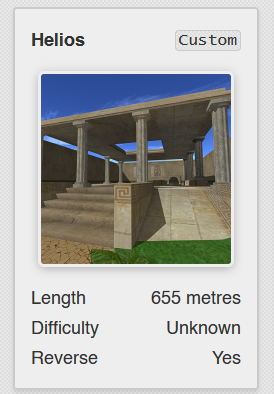
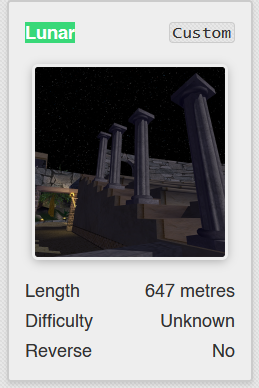

In [33]:
# Predict my time when playing Toyeca at Quake!
my_tier = player_tiers.filter(col('Player') == 'VALI2WD').select('Skill_Tier').collect()

supposed_race = sparkRVGL.createDataFrame([
    Row(Track='Quake!', Cars='Toyeca', Skill_Tier=int(my_tier[0]['Skill_Tier']))
])

In [34]:
my_prediction = personalized_lr_model.transform(supposed_race)

In [35]:
# UDF care transforma din milisecunde in mm:ss
format_time_udf = udf(format_race_time_from_ms, StringType())

my_prediction\
            .select("Track", \
                    "Cars", \
                    "Skill_Tier", \
                    col("prediction"))\
            .withColumn("prediction", format_time_udf(col("prediction")))\
            .show()

+------+------+----------+----------+
| Track|  Cars|Skill_Tier|prediction|
+------+------+----------+----------+
|Quake!|Toyeca|         3|  03:34.73|
+------+------+----------+----------+



Harta ``Quake!``

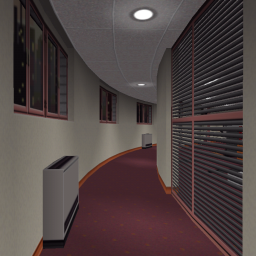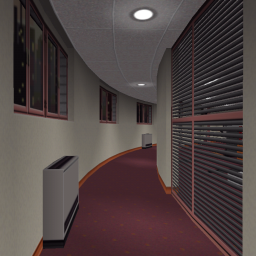

In [36]:
# Hyperparameter Tuning pentru regresie liniara
# ElasticNetParam = 0.0 = Ridge; 0.5 = Elastic Net Pur; 1.0 Lasso Regression
# Reg Param = 0.1 penalizare slaba, 0.5 penaleizare severa.
paramGrid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.1, 0.5]) \
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]) \
    .build()

evaluator = RegressionEvaluator(labelCol="Time(ms)", predictionCol="prediction", metricName="rmse")

crossval = CrossValidator(
    estimator=personalized_pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3
)

print("Training multiple models to find the best hyperparameters. This might take a minute...")
cvModel = crossval.fit(train_data) 

optimized_predictions = cvModel.transform(test_data)
optimized_rmse = evaluator.evaluate(optimized_predictions)
print(f"Optimized Model RMSE: {format_race_time_from_ms(optimized_rmse)} seconds")

Training multiple models to find the best hyperparameters. This might take a minute...
Optimized Model RMSE: 00:47.24 seconds


<h1>Aplicarea a cel puțin unei metode Deep Learning</h1>

In [1]:
from pyspark import SparkContext as sc
from pyspark.sql import SparkSession, functions, Column, Row
from pyspark.sql.functions import when, col, regexp_replace, count, avg, stddev, sum
import pandas as pd
import os
import io
import csv
import pandas as pd
import re
import pyspark.pandas as ps
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import udf, col
from pyspark.sql.types import StringType
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

/usr/local/spark/python/pyspark/pandas/__init__.py:50: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


In [2]:
pdf_results = pd.read_csv("Final_Player_Predictions.csv")

In [3]:
pdf_results

,Cars,Track,Car_Vec,features,Car_Index,prediction,Time(ms),Skill_Tier
0,AMW,Airport 1,"(3027,[20],[1.0])","(3264,[30,254,3261],[1.0,1.0,1.0])",20.0,216481.512502,310717,0
1,APC L-13,Airport 1,"(3027,[136],[1.0])","(3264,[30,370],[1.0,1.0])",136.0,174623.185091,174205,3
2,Acclaim GT,Airport 1,"(3027,[12],[1.0])","(3264,[30,246,3261],[1.0,1.0,1.0])",12.0,209771.257362,211070,0
3,Acclaim GT,Airport 1,"(3027,[12],[1.0])","(3264,[30,246],[1.0,1.0])",12.0,178557.215232,171172,3
4,Adeon,Airport 1,"(3027,[6],[1.0])","(3264,[30,240,3261],[1.0,1.0,1.0])",6.0,212461.127839,196546,0
...,...,...,...,...,...,...,...,...
288656,Random,urbanX R,"(3027,[2],[1.0])","(3264,[119,236,3261],[1.0,1.0,1.0])",2.0,227047.144463,151517,0
288657,Random,urbanX R,"(3027,[2],[1.0])","(3264,[119,236,3261],[1.0,1.0,1.0])",2.0,227047.144463,198032,0
288658,Random,urbanX R,"(3027,[2],[1.0])","(3264,[119,236,3262],[1.0,1.0,1.0])",2.0,263776.730086,288032,1
288659,Random,urbanX R,"(3027,[2],[1.0])","(3264,[119,236,3263],[1.0,1.0,1.0])",2.0,215517.321229,165551,2


In [4]:
#Curse of dimensionality
pdf_sampled = pdf_results.sample(frac = 0.10, random_state=42)

In [5]:
tf_data = pd.get_dummies(pdf_sampled[["Track", "Cars", "Skill_Tier"]], columns=["Track", "Cars"])
y = pdf_sampled["Time(ms)"].values 

In [6]:
tf_data

,Skill_Tier,Track_Airport 1,Track_Aquarium 1,Track_Aquarium 1 R,Track_Aspenside,Track_Aspenside R,Track_Biohazard Factory,Track_Biohazard Factory M,Track_Biohazard Factory R,Track_Botanical Garden,...,"Cars_Zipper,Maxam RS","Cars_Zipper,Panga","Cars_Zipper,Pemto","Cars_Zipper,Quazar","Cars_Zipper,Quazar,Adeon,Gravel Basher,Heritage,AMW","Cars_Zipper,RG1","Cars_Zipper,Rothams Racing","Cars_Zipper,Sokudo","Cars_Zipper,Speed Balancer,CHC 305,Sokudo","Cars_Zipper,Toy-World GT"
48413,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
81536,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
145671,1,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
138846,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
111087,2,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232904,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
30645,3,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
46711,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
156156,2,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [7]:
X = tf_data.values
y = pdf_sampled["Time(ms)"].values

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Scalarea datelor
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Tensorflow Sequential
# Multi layer perceptron - foloseste functii de activare non-liniare (relu)
# invata automat pe interactiunile complexe, masina, skillTier, harta
# Overfitting, Dropout(0.2) - opreste 20% din neuroni
# Al doilea strat de procesare condensează informația extrasă de stratul anterior, folosind 32 de neuroni
# optimizator = adam, standard (Adaptive Moment Estimation)
# rmse pentru functie de pierdere, pentru consistenta(am folosit si la regresie drept metrica).
# motivatie: intrare unica(vector de harta, masina, skilltier) iesire unica(timp) si este optimizat pentru flux liniar(feed-forward).
# compatibilitate directa cu regularizare ( Dropout ), RMSE pentru fiecare epoca.
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2), 
    Dense(32, activation='relu'),
    Dense(1) 
])

model.compile(
    optimizer='adam', 
    loss='mean_squared_error', 
    metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)

/opt/conda/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
print("Training Deep Learning Model...")
history = model.fit(
    X_train_scaled, y_train, 
    epochs=50, 
    batch_size=32, 
    validation_split=0.2,
    verbose=1
)

Training Deep Learning Model...
Epoch 1/50
578/578 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 42192433152.0000 - rmse: 205407.9688 - val_loss: 34861748224.0000 - val_rmse: 186713.0156
Epoch 2/50
578/578 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 21768699904.0000 - rmse: 147542.2031 - val_loss: 14056385536.0000 - val_rmse: 118559.6250
Epoch 3/50
578/578 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 12761000960.0000 - rmse: 112964.6016 - val_loss: 12981703680.0000 - val_rmse: 113937.2812
Epoch 4/50
578/578 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 12159463424.0000 - rmse: 110269.9609 - val_loss: 12569979904.0000 - val_rmse: 112115.9219
Epoch 5/50
578/578 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 11696541696.0000 - rmse: 108150.5547 - val_loss: 12208115712.0000 - val_rmse: 110490.3438
Epoch 6/50
578/578 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 11281910784.0000 - rmse: 106216.3359 - val_loss: 11882487808.0000 - val_rmse: 109006.8281
Epoch 7/50
578/578 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 10904597

In [11]:
print("\n---TensorFlow Evaluation ---")
test_loss, test_rmse = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Deep Learning RMSE: {test_rmse:.2f} seconds")


---TensorFlow Evaluation ---
Deep Learning RMSE: 85701.09 seconds


In [ ]:
# Este un rezultat mai slab decat regresia liniara simpla.